### Как запускать программу

Условие задачи

\begin{align}
   y'(x) &= -A y(X), \quad A = 1000 \\
   y_0 &= 1, \quad x \in [0, 1]
\end{align}

Точное решение $y = e^{-A x}$

Как устроена программа? - Есть 4 схемы: 

$\textbf{I. }$ $\textit{Явный метод Эйлера}$ (в task_2.cpp это функция $\textit{ExplicitEulerMethod}$): 

формула $y_{k+1} = (1 - Ah) \cdot y_k$

Свойства: 

1) Простейший метод, но может быть неустойчив при больших A или больших шагах h. 

2) Ошибка $\text{O(h)}$.

$\textbf{II. }$ $\textit{Неявный метод Эйлера}$ (в task_2.cpp это функция $\textit{ImplicitEulerMethod}$): 

формула $y_{k+1} = \frac{y_k}{1 + Ah}$

Свойства: 

1) Более устойчив, чем явный Эйлер. 

2) Ошибка $\text{O(h)}$.

$\textbf{III. }$ $\textit{Метод трапеций (Кранка-Николсон)}$ (в task_2.cpp это функция $\textit{TrapezoidalApproach}$): 

формула $y_{k+1} = \frac{2 - Ah}{2 + Ah} \cdot y_k$

Свойства: 

1) Второй порядок точности $\text{O(h}^2)$. 

2) Точнее, чем методы Эйлера, но сложнее. Устойчив при любых шагах.

$\textbf{IV. }$ $\textit{Двухшаговый метод (похож на метод Адамса)}$ (в task_2.cpp это функция $\textit{LeapfrogTechnique}$): 

формула $y_{k+1} = y_{k + 1} - 2Ah \cdot y_k$

Свойства: 

1) Использует два предыдущих значения, второй порядок точности $\text{O(h}^2)$.

2) Может быть менее устойчивым (т.е. может быть неустойчивым), чем неявные методы.

Если мы возмем для всех 4-ёх схем шаг $h = 1/N$, то 4-ая схема будет падать на университетских компьютерах (возникнет неустойчивость, и это будет видно на этих компьютерах, но в моем компьютере при таком шаге ошибка будет 0),  поэтому в 4-ой схеме лучше брать меньший шаг $h = 0.01/N$ (при таком шаге ошибка будет приблизительно при данном запуске порядка е-7, е-8).

Программа запускается в терминале следующим образом (где число N = 1000 - это размер сетки, а A = 1000 - это параметр из условия задачи, т.е. константа - имеется возможность N и A, но в условиях данной задачи будем брать A = 1000, но при необходимости можно менять параметр A): 

Сначала пишется команда ```make clean``` (для очистки ненужных файлов типа .o)

После идет команда в терминале ```make```

И в конце пишем в терминале ```./a.out 1000 1000```

Если что-то в программе изменилось, или есть необходимость удалить ненужные файлы, то нужно использовать команду make clean, после ```make``` и в конце ```./a.out 1000 1000```

Результат данного запуска записывается в файле output.txt, этот результат можно посмотреть, написав команду в терминале ```cat output.txt```:

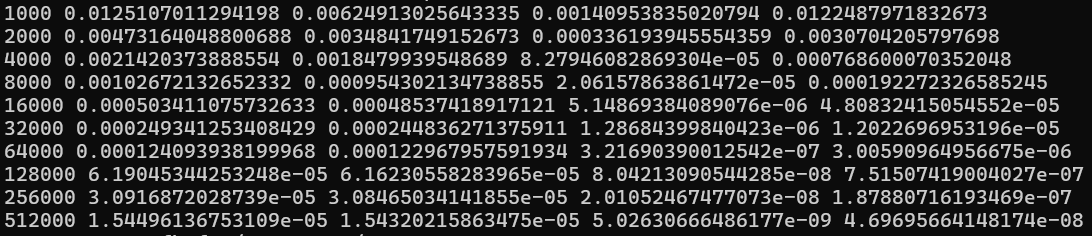

1-ый столбец соответствует числу N

2-ой столбец - ошибкам схемы $\textbf{I}$ для различных N из 1-ого столбца

3-ий столбец - ошибкам схемы $\textbf{II}$ для различных N из 1-ого столбца

4-ый столбец - ошибкам схемы $\textbf{III}$ для различных N из 1-ого столбца

5-ый столбец - ошибкам схемы $\textbf{IV}$ для различных N из 1-ого столбца

### Вычисление ошибки

Для каждой схемы вычисляется $L_2$-норма ошибки (корень из суммы квадратов разностей численного и аналитического решений), т.е.

${error} = \sqrt{h \sum_{k=1}^N (y_{числ} − y_{точн})^2}$
 
Чем меньше ошибка, тем точнее схема.

### График для анализа (с помощью Python)

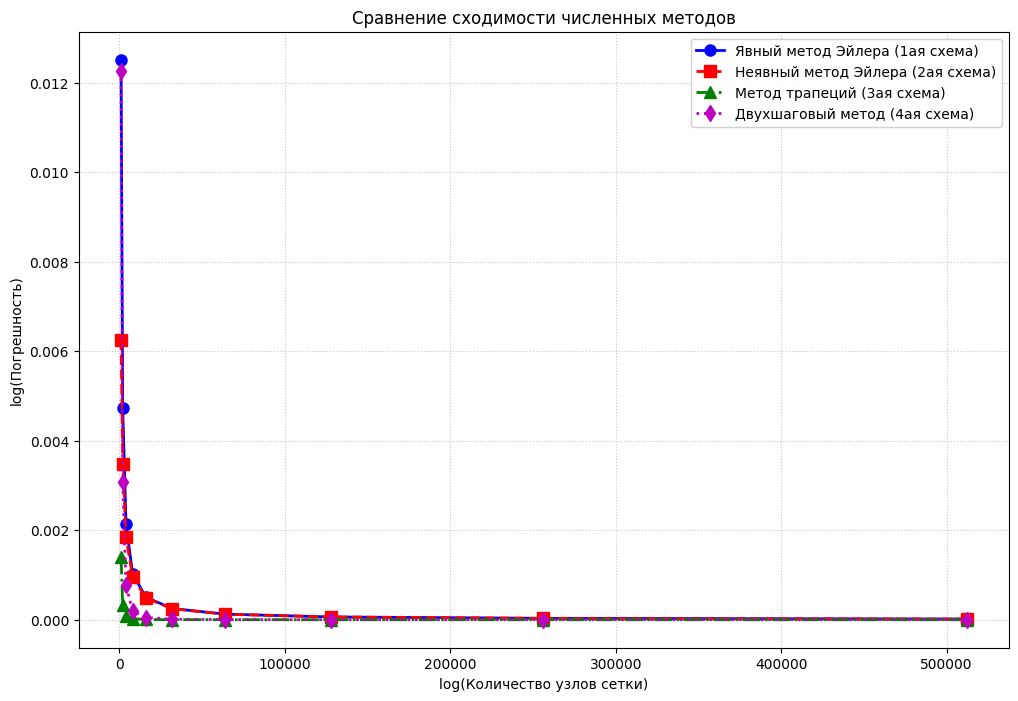

Для N = 2000.0, показатель сходимости 1ой схемы = 1.401738377987653, 2ой схемы = 0.8422303619971269, 3ей схемы = 2.0663653956842243, 4ой схемы = 1.9946919476506393
Для N = 4000.0, показатель сходимости 1ой схемы = 1.142944414296775, 2ой схемы = 0.914527045969468, 3ей схемы = 2.020955839068906, 4ой схемы = 1.9974105890562606
Для N = 8000.0, показатель сходимости 1ой схемы = 1.0607476770630393, 2ой схемы = 0.9532700904744753, 3ей схемы = 2.0054256065628238, 4ой схемы = 1.9987214645828009
Для N = 16000.0, показатель сходимости 1ой схемы = 1.0281430794359523, 2ой схемы = 0.9752607617911635, 3ей схемы = 2.001290633316566, 4ой схемы = 1.9993647736385909
Для N = 32000.0, показатель сходимости 1ой схемы = 1.0135696640914962, 2ой схемы = 0.987235578699986, 3ей схемы = 2.0002791307699037, 4ой схемы = 1.9996834391088605
Для N = 64000.0, показатель сходимости 1ой схемы = 1.0066662592364088, 2ой схемы = 0.9935124722621899, 3ей схемы = 2.00004733926255, 4ой схемы = 1.9998419275424317
Для N = 128000.

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def load_convergence_data(input_file):
    raw_data = np.genfromtxt(input_file)
    x_vals = raw_data[:, 0]  # Логарифмы количества точек
    y_vals = raw_data[:, 1:] # Логарифмы ошибок для каждого метода
    return x_vals, y_vals

def visualize_methods_convergence(x_data, y_data):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    method_names = ['Явный метод Эйлера (1ая схема)', 
                  'Неявный метод Эйлера (2ая схема)', 
                  'Метод трапеций (3ая схема)', 
                  'Двухшаговый метод (4ая схема)']
    line_styles = ['b-o', 'r--s', 'g-.^', 'm:d']
    
    for method_idx in range(y_data.shape[1]):
        ax.plot(x_data, 
               y_data[:, method_idx], 
               line_styles[method_idx],
               linewidth=2,
               markersize=8,
               label=method_names[method_idx])
    
    ax.set(xlabel='log(Количество узлов сетки)',
          ylabel='log(Погрешность)',
          title='Сравнение сходимости численных методов')
    
    ax.grid(which='both', linestyle=':', alpha=0.7)
    ax.legend(fontsize=10, framealpha=0.9)
    
    plt.savefig('2.png')
    plt.show()

def convergence_rate(errors, N_array):
    rate = []
    for i in range(1, len(errors)):
        rate_i = np.log(errors[i - 1]/errors[i])/np.log((N_array[i] - 1) / (N_array[i - 1] - 1))
        rate.append(rate_i)
    return rate


input_data_file = 'output.txt'
log_points, log_errors = load_convergence_data(input_data_file)
visualize_methods_convergence(log_points, log_errors)
rate_1_scheme = convergence_rate(log_errors[:, 0], log_points)
rate_2_scheme = convergence_rate(log_errors[:, 1], log_points)
rate_3_scheme = convergence_rate(log_errors[:, 2], log_points)
rate_4_scheme = convergence_rate(log_errors[:, 3], log_points)

for i in range(0, len(log_points) - 1):
    print(f'Для N = {log_points[i+1]}, показатель сходимости 1ой схемы = {rate_1_scheme[i]}, 2ой схемы = {rate_2_scheme[i]}, 3ей схемы = {rate_3_scheme[i]}, 4ой схемы = {rate_4_scheme[i]}')
